Code for Experiment 3
----------------------

This notebook contains the python code used to analyze the data collected during Experiment 3 of the paper "Building Compressed Causal Models of the World." It requires that R also be installed on your computer in order to run mixed ANOVAs.

In [1]:
#Import all required packages.

import os
os.environ['R_HOME']='/Library/Frameworks/R.framework/Resources' #The home for R on your computer may differ, please update appropriately. 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import statsmodels.formula.api as smf
import scipy.stats as stats
import rpy2.robjects as ro
import rpy2.robjects.packages as rpackages
from rpy2.robjects import pandas2ri, StrVector
from rpy2.robjects.conversion import localconverter

The following block of code imports and cleans the data in the file 'study_3_data.csv'.

In [2]:
#Import data and remove labels. 
data = pd.read_csv('study_3_data.csv')
data=data.drop(labels=0,axis=0) 
data=data.drop(labels=1,axis=0)

#Remove all data from participants who failed comprehension checks.
inclusions = []
for i in range(2,len(data)):
    if data.D_CompCheck[i] == 'Drol' or data.B_CompCheck[i] == 'Bricofly' or data.C_CompCheck[i] == 'Chapagite':
        inclusions = np.append(inclusions,[i])

exclusions = [x for x in np.arange(2,len(data)) if x not in inclusions]

data=data.drop(labels=exclusions,axis=0)

#Remove all data from participants who rated any of the poor causal claims positively. 
for i in range(0,4):
    s = str(i)
    data = data[data.B_PropCompBad1_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_PropHighBad1_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_PropLowBad1_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_PropCompBad2_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_PropHighBad2_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_PropLowBad2_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_PropCompBad3_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_PropHighBad3_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_PropLowBad3_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_StabCompBad1_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_StabHighBad1_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_StabLowBad1_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_StabCompBad2_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_StabHighBad2_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_StabLowBad2_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_StabCompBad3_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_StabHighBad3_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_StabLowBad3_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_PropCompBad1_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_PropHighBad1_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_PropLowBad1_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_PropCompBad2_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_PropHighBad2_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_PropLowBad2_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_PropCompBad3_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_PropHighBad3_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_PropLowBad3_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_StabCompBad1_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_StabHighBad1_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_StabLowBad1_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_StabCompBad2_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_StabHighBad2_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_StabLowBad2_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_StabCompBad3_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_StabHighBad3_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_StabLowBad3_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_PropCompBad1_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_PropHighBad1_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_PropLowBad1_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_PropCompBad2_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_PropHighBad2_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_PropLowBad2_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_PropCompBad3_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_PropHighBad3_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_PropLowBad3_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_StabCompBad1_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_StabHighBad1_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_StabLowBad1_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_StabCompBad2_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_StabHighBad2_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_StabLowBad2_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_StabCompBad3_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_StabHighBad3_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_StabLowBad3_1 != s]
data = data.reset_index()

The following block constructs arrays whose values denote:

1. The scenarip shown to each participant (vignette).
2. Whether the participant was shown a vignette in which compression involved coarsening a causal variable or eliding a background variable (mode).
3. The participant's evaluation of the causal claim Compressed (comp_eval).
4. The participant's evaluation of the causal claim High (high_eval).
5. The participant's evaluation of the causal claim Low (low_eval).

In [3]:
scenario = []
for i in range(0,len(data)):
    if data.Group[i] == '1':
        scenario = np.append(scenario,[1])
    if data.Group[i] == '2':
        scenario = np.append(scenario,[2])
    if data.Group[i] == '3':
        scenario = np.append(scenario,[3])
        
mode = []
for i in range(0,len(data)):
    if data.Mode[i] == 'Proportionality':
        mode = np.append(mode,[-1])
    if data.Mode[i] == 'Stability':
        mode = np.append(mode,[1])
        
vignette = []
for i in range(0,len(data)):
    if data.Vignette[i] == 'Bricofly':
        vignette = np.append(vignette,[-1])
    if data.Vignette[i] == 'Drol':
        vignette = np.append(vignette,[0])
    if data.Vignette[i] == 'Drol':
        vignette = np.append(vignette,[1])
        
comp_eval = []
for i in range(0,len(data)):
    if data.Vignette[i] == 'Bricofly':
        if data.Group[i] == '1' and data.Mode[i] == 'Proportionality' :
            comp_eval = np.append(comp_eval,[int(data.B_PropCompGood1_1[i])])
        if data.Group[i] == '1' and data.Mode[i] == 'Stability' :
            comp_eval = np.append(comp_eval,[int(data.B_StabCompGood1_1[i])])
        if data.Group[i] == '2' and data.Mode[i] == 'Proportionality' :
            comp_eval = np.append(comp_eval,[int(data.B_PropCompGood2_1[i])])
        if data.Group[i] == '2' and data.Mode[i] == 'Stability' :
            comp_eval = np.append(comp_eval,[int(data.B_StabCompGood2_1[i])])
        if data.Group[i] == '3' and data.Mode[i] == 'Proportionality' :
            comp_eval = np.append(comp_eval,[int(data.B_PropCompGood3_1[i])])
        if data.Group[i] == '3' and data.Mode[i] == 'Stability' :
            comp_eval = np.append(comp_eval,[int(data.B_StabCompGood3_1[i])])
    if data.Vignette[i] == 'Chapagite':
        if data.Group[i] == '1' and data.Mode[i] == 'Proportionality' :
            comp_eval = np.append(comp_eval,[int(data.C_PropCompGood1_1[i])])
        if data.Group[i] == '1' and data.Mode[i] == 'Stability' :
            comp_eval = np.append(comp_eval,[int(data.C_StabCompGood1_1[i])])
        if data.Group[i] == '2' and data.Mode[i] == 'Proportionality' :
            comp_eval = np.append(comp_eval,[int(data.C_PropCompGood2_1[i])])
        if data.Group[i] == '2' and data.Mode[i] == 'Stability' :
            comp_eval = np.append(comp_eval,[int(data.C_StabCompGood2_1[i])])
        if data.Group[i] == '3' and data.Mode[i] == 'Proportionality' :
            comp_eval = np.append(comp_eval,[int(data.C_PropCompGood3_1[i])])
        if data.Group[i] == '3' and data.Mode[i] == 'Stability' :
            comp_eval = np.append(comp_eval,[int(data.C_StabCompGood3_1[i])])
    if data.Vignette[i] == 'Drol':
        if data.Group[i] == '1' and data.Mode[i] == 'Proportionality' :
            comp_eval = np.append(comp_eval,[int(data.D_PropCompGood1_1[i])])
        if data.Group[i] == '1' and data.Mode[i] == 'Stability' :
            comp_eval = np.append(comp_eval,[int(data.D_StabCompGood1_1[i])])
        if data.Group[i] == '2' and data.Mode[i] == 'Proportionality' :
            comp_eval = np.append(comp_eval,[int(data.D_PropCompGood2_1[i])])
        if data.Group[i] == '2' and data.Mode[i] == 'Stability' :
            comp_eval = np.append(comp_eval,[int(data.D_StabCompGood2_1[i])])
        if data.Group[i] == '3' and data.Mode[i] == 'Proportionality' :
            comp_eval = np.append(comp_eval,[int(data.D_PropCompGood3_1[i])])
        if data.Group[i] == '3' and data.Mode[i] == 'Stability' :
            comp_eval = np.append(comp_eval,[int(data.D_StabCompGood3_1[i])])

            
high_eval = []
for i in range(0,len(data)):
    if data.Vignette[i] == 'Bricofly':
        if data.Group[i] == '1' and data.Mode[i] == 'Proportionality' :
            high_eval = np.append(high_eval,[int(data.B_PropHighGood1_1[i])])
        if data.Group[i] == '1' and data.Mode[i] == 'Stability' :
            high_eval = np.append(high_eval,[int(data.B_StabHighGood1_1[i])])
        if data.Group[i] == '2' and data.Mode[i] == 'Proportionality' : 
            high_eval = np.append(high_eval,[int(data.B_PropHighGood2_1[i])])
        if data.Group[i] == '2' and data.Mode[i] == 'Stability' :
            high_eval = np.append(high_eval,[int(data.B_StabHighGood2_1[i])])
        if data.Group[i] == '3' and data.Mode[i] == 'Proportionality' :
            high_eval = np.append(high_eval,[int(data.B_PropHighGood3_1[i])])
        if data.Group[i] == '3' and data.Mode[i] == 'Stability' :
            high_eval = np.append(high_eval,[int(data.B_StabHighGood3_1[i])])
    if data.Vignette[i] == 'Chapagite':
        if data.Group[i] == '1' and data.Mode[i] == 'Proportionality' :
            high_eval = np.append(high_eval,[int(data.C_PropHighGood1_1[i])])
        if data.Group[i] == '1' and data.Mode[i] == 'Stability' :
            high_eval = np.append(high_eval,[int(data.C_StabHighGood1_1[i])])
        if data.Group[i] == '2' and data.Mode[i] == 'Proportionality' :
            high_eval = np.append(high_eval,[int(data.C_PropHighGood2_1[i])])
        if data.Group[i] == '2' and data.Mode[i] == 'Stability' :
            high_eval = np.append(high_eval,[int(data.C_StabHighGood2_1[i])])
        if data.Group[i] == '3' and data.Mode[i] == 'Proportionality' :
            high_eval = np.append(high_eval,[int(data.C_PropHighGood3_1[i])])
        if data.Group[i] == '3' and data.Mode[i] == 'Stability' :
            high_eval = np.append(high_eval,[int(data.C_StabHighGood3_1[i])])
    if data.Vignette[i] == 'Drol':
        if data.Group[i] == '1' and data.Mode[i] == 'Proportionality' :
            high_eval = np.append(high_eval,[int(data.D_PropHighGood1_1[i])])
        if data.Group[i] == '1' and data.Mode[i] == 'Stability' :
            high_eval = np.append(high_eval,[int(data.D_StabHighGood1_1[i])])
        if data.Group[i] == '2' and data.Mode[i] == 'Proportionality' :
            high_eval = np.append(high_eval,[int(data.D_PropHighGood2_1[i])])
        if data.Group[i] == '2' and data.Mode[i] == 'Stability' :
            high_eval = np.append(high_eval,[int(data.D_StabHighGood2_1[i])])
        if data.Group[i] == '3' and data.Mode[i] == 'Proportionality' :
            high_eval = np.append(high_eval,[int(data.D_PropHighGood3_1[i])])
        if data.Group[i] == '3' and data.Mode[i] == 'Stability' :
            high_eval = np.append(high_eval,[int(data.D_StabHighGood3_1[i])])

low_eval = []
for i in range(0,len(data)):
    if data.Vignette[i] == 'Bricofly':
        if data.Group[i] == '1' and data.Mode[i] == 'Proportionality' :
            low_eval = np.append(low_eval,[int(data.B_PropLowGood1_1[i])])
        if data.Group[i] == '1' and data.Mode[i] == 'Stability' :
            low_eval = np.append(low_eval,[int(data.B_StabLowGood1_1[i])])
        if data.Group[i] == '2' and data.Mode[i] == 'Proportionality' : 
            low_eval = np.append(low_eval,[int(data.B_PropLowGood2_1[i])])
        if data.Group[i] == '2' and data.Mode[i] == 'Stability' :
            low_eval = np.append(low_eval,[int(data.B_StabLowGood2_1[i])])
        if data.Group[i] == '3' and data.Mode[i] == 'Proportionality' :
            low_eval = np.append(low_eval,[int(data.B_PropLowGood3_1[i])])
        if data.Group[i] == '3' and data.Mode[i] == 'Stability' :
            low_eval = np.append(low_eval,[int(data.B_StabLowGood3_1[i])])
    if data.Vignette[i] == 'Chapagite':
        if data.Group[i] == '1' and data.Mode[i] == 'Proportionality' :
            low_eval = np.append(low_eval,[int(data.C_PropLowGood1_1[i])])
        if data.Group[i] == '1' and data.Mode[i] == 'Stability' :
            low_eval = np.append(low_eval,[int(data.C_StabLowGood1_1[i])])
        if data.Group[i] == '2' and data.Mode[i] == 'Proportionality' :
            low_eval = np.append(low_eval,[int(data.C_PropLowGood2_1[i])])
        if data.Group[i] == '2' and data.Mode[i] == 'Stability' :
            low_eval = np.append(low_eval,[int(data.C_StabLowGood2_1[i])])
        if data.Group[i] == '3' and data.Mode[i] == 'Proportionality' :
            low_eval = np.append(low_eval,[int(data.C_PropLowGood3_1[i])])
        if data.Group[i] == '3' and data.Mode[i] == 'Stability' :
            low_eval = np.append(low_eval,[int(data.C_StabLowGood3_1[i])])
    if data.Vignette[i] == 'Drol':
        if data.Group[i] == '1' and data.Mode[i] == 'Proportionality' :
            low_eval = np.append(low_eval,[int(data.D_PropLowGood1_1[i])])
        if data.Group[i] == '1' and data.Mode[i] == 'Stability' :
            low_eval = np.append(low_eval,[int(data.D_StabLowGood1_1[i])])
        if data.Group[i] == '2' and data.Mode[i] == 'Proportionality' :
            low_eval = np.append(low_eval,[int(data.D_PropLowGood2_1[i])])
        if data.Group[i] == '2' and data.Mode[i] == 'Stability' :
            low_eval = np.append(low_eval,[int(data.D_StabLowGood2_1[i])])
        if data.Group[i] == '3' and data.Mode[i] == 'Proportionality' :
            low_eval = np.append(low_eval,[int(data.D_PropLowGood3_1[i])])
        if data.Group[i] == '3' and data.Mode[i] == 'Stability' :
            low_eval = np.append(low_eval,[int(data.D_StabLowGood3_1[i])])


The next block generates the Figure showing the main experimental findings.

/var/folders/09/dm7f60811cqgm3lr35c86qfw0000gn/T/ipykernel_36062/1797430198.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(['0','1','2','3'],fontsize=30)


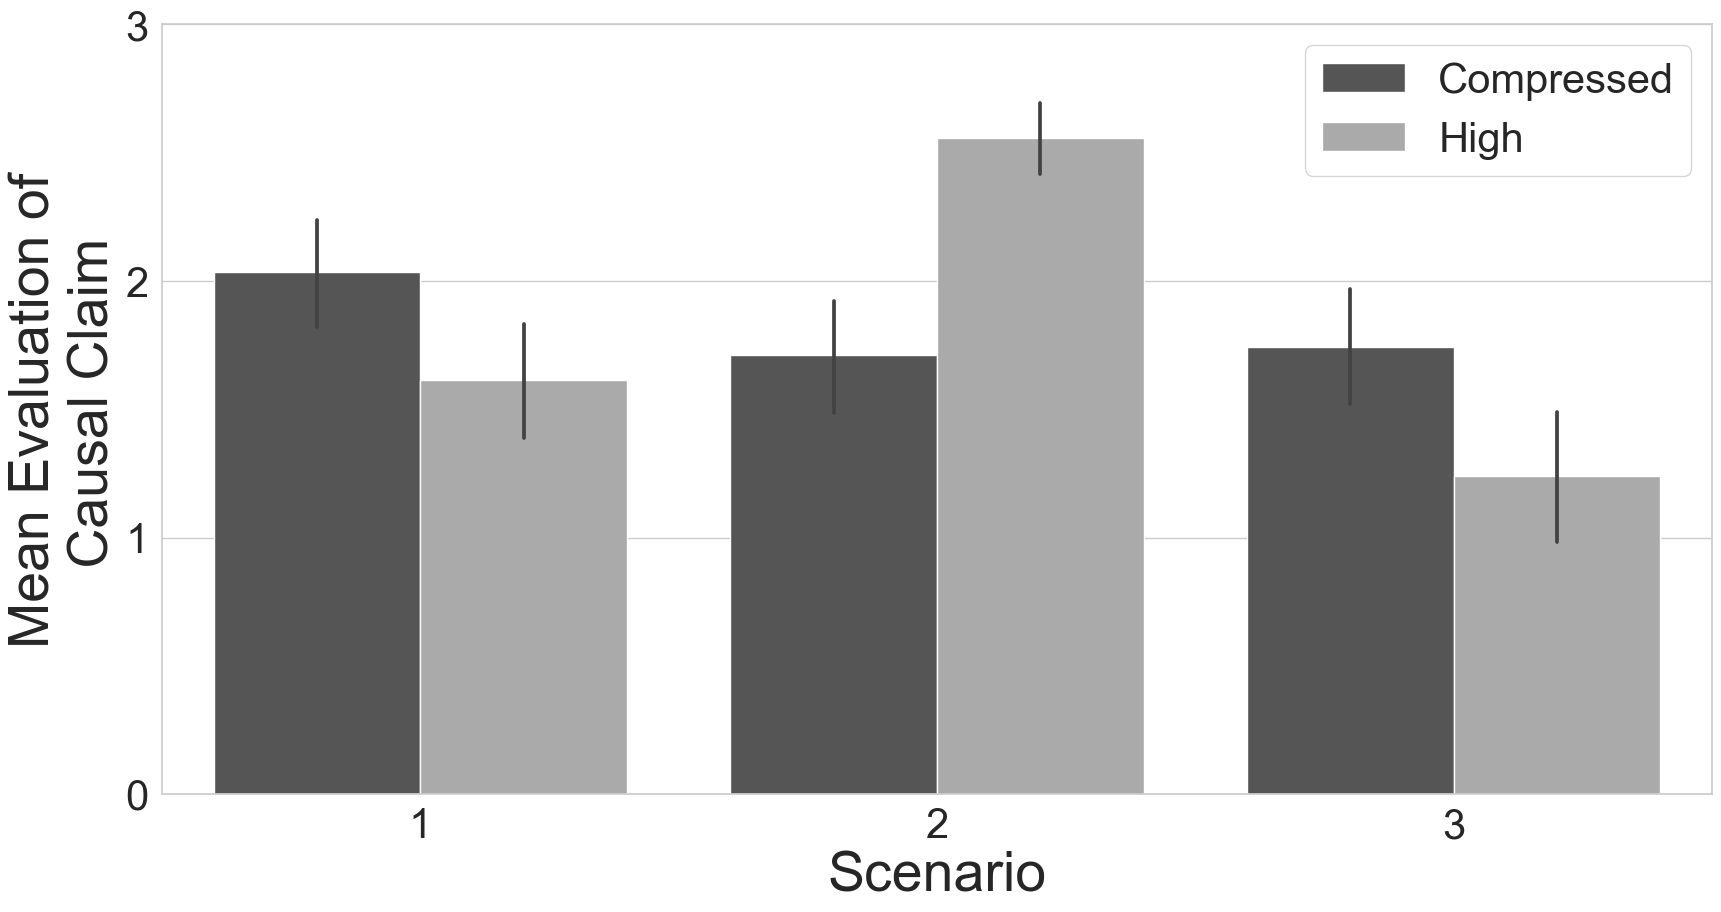

In [5]:
arr = np.hstack((scenario.reshape(-1,1),comp_eval.reshape(-1,1),high_eval.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Scenario', 'Compressed', 'High'])
datamelt = df.melt('Scenario', value_vars=['Compressed','High'],var_name='kind')
ax=sns.barplot(x='Scenario', y='value', hue='kind', dodge=True, palette='gray', data=datamelt)
sns.set(rc = {'figure.figsize':(20,10)})
sns.set_style('whitegrid')
ax.set_ylabel('Mean Evaluation of\n Causal Claim',fontsize=40)
ax.set_xlabel('Scenario',fontsize=40)
ax.set_xticklabels(['1','2','3'],fontsize=30)
ax.set_yticklabels(['0','1','2','3'],fontsize=30)
plt.yticks(ticks=[0,1,2,3],fontsize=30)
plt.legend(fontsize=30)
plt.savefig('study3_barplot')

The next three blocks generate the results of ANOVA comparing the difference between Compressed and High across the three scenarios.

In [6]:
subject_1=[]
for i in range(0,len(data.Group)):
    if data.Group[i] == '1':
        subject_1 = np.append(subject_1,[i,i])

evals_high_1 = []
for i in range(0,len(data.Group)):
    if data.Group[i] == '1':
        evals_high_1 = np.append(evals_high_1,[comp_eval[i],high_eval[i]])
    
    
vignette_for_anova_1 = []
for i in range(0,len(data.Group)): 
    if data.Group[i] == '1':
        vignette_for_anova_1 = np.append(vignette_for_anova_1,[vignette[i],vignette[i]])
    
mode_for_anova_1 = []
for i in range(0,len(data.Group)):
    if data.Group[i] == '1':                                                       
        mode_for_anova_1 = np.append(mode_for_anova_1,[mode[i],mode[i]])
    
    
diff_type_1 = []
for i in range(0,len(data.Group)):
    if data.Group[i] == '1':
        diff_type_1 = np.append(diff_type_1,[-1,1])

arr = np.hstack((subject_1.reshape(-1,1),vignette_for_anova_1.reshape(-1,1),mode_for_anova_1.reshape(-1,1),evals_high_1.reshape(-1,1),diff_type_1.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Subject','Vignette', 'Mode', 'Eval_High','Diff_Type'])


packageNames = ("afex", "emmeans")
utils = rpackages.importr("utils")
utils.chooseCRANmirror(ind=1)

packnames_to_install = [x for x in packageNames if not rpackages.isinstalled(x)]

if len(packnames_to_install) > 0:
    utils.install_packages(StrVector(packnames_to_install))

# convert pandas DF ("tmp") to R data.frame
with localconverter(ro.default_converter + pandas2ri.converter):
    r_from_pd_df = ro.conversion.py2rpy(df)

r_from_pd_df.head()

afex = rpackages.importr("afex")

model = afex.aov_ez(
    id="Subject",
    dv="Eval_High",
    between=["Vignette", "Mode"],
    within="Diff_Type",
    data=r_from_pd_df,
    check_contrasts=True,  # 3-way interaction is unaffected by this, "True" is recommended
    type=3,  # using so-called type 3 sums of squares
    print_formula=True,
)

print(model)

R[write to console]: Formula send to aov_car: Eval_High ~ Vignette * Mode + Error(Subject/(Diff_Type))

R[write to console]: Converting to factor: Vignette, Mode

R[write to console]: Contrasts set to contr.sum for the following variables: Vignette, Mode



Anova Table (Type 3 tests)

Response: Eval_High
                   Effect     df  MSE        F   ges p.value
1                Vignette 2, 167 2.92     0.12 <.001    .890
2                    Mode 1, 167 2.92  7.76 **  .031    .006
3           Vignette:Mode 2, 167 2.92     1.77  .015    .173
4               Diff_Type 1, 167 1.29 10.77 **  .019    .001
5      Vignette:Diff_Type 2, 167 1.29     0.72  .003    .490
6          Mode:Diff_Type 1, 167 1.29     0.65  .001    .422
7 Vignette:Mode:Diff_Type 2, 167 1.29     2.17  .008    .117
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘+’ 0.1 ‘ ’ 1



In [7]:
subject_2=[]
for i in range(0,len(data.Group)):
    if data.Group[i] == '2':
        subject_2 = np.append(subject_2,[i,i])

evals_high_2 = []
for i in range(0,len(data.Group)):
    if data.Group[i] == '2':
        evals_high_2 = np.append(evals_high_2,[comp_eval[i],high_eval[i]])
    
    
vignette_for_anova_2 = []
for i in range(0,len(data.Group)): 
    if data.Group[i] == '2':
        vignette_for_anova_2 = np.append(vignette_for_anova_2,[vignette[i],vignette[i]])
    
mode_for_anova_2 = []
for i in range(0,len(data.Group)):
    if data.Group[i] == '2':                                                       
        mode_for_anova_2 = np.append(mode_for_anova_2,[mode[i],mode[i]])
    
    
diff_type_2 = []
for i in range(0,len(data.Group)):
    if data.Group[i] == '2':
        diff_type_2 = np.append(diff_type_2,[-1,1])

arr = np.hstack((subject_2.reshape(-1,1),vignette_for_anova_2.reshape(-1,1),mode_for_anova_2.reshape(-1,1),evals_high_2.reshape(-1,1),diff_type_2.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Subject','Vignette', 'Mode', 'Eval_High','Diff_Type'])


packageNames = ("afex", "emmeans")
utils = rpackages.importr("utils")
utils.chooseCRANmirror(ind=1)

packnames_to_install = [x for x in packageNames if not rpackages.isinstalled(x)]

if len(packnames_to_install) > 0:
    utils.install_packages(StrVector(packnames_to_install))

# convert pandas DF ("tmp") to R data.frame
with localconverter(ro.default_converter + pandas2ri.converter):
    r_from_pd_df = ro.conversion.py2rpy(df)

r_from_pd_df.head()

afex = rpackages.importr("afex")

model = afex.aov_ez(
    id="Subject",
    dv="Eval_High",
    between=["Vignette", "Mode"],
    within="Diff_Type",
    data=r_from_pd_df,
    check_contrasts=True,  # 3-way interaction is unaffected by this, "True" is recommended
    type=3,  # using so-called type 3 sums of squares
    print_formula=True,
)

print(model)


R[write to console]: Formula send to aov_car: Eval_High ~ Vignette * Mode + Error(Subject/(Diff_Type))

R[write to console]: Converting to factor: Vignette, Mode

R[write to console]: Contrasts set to contr.sum for the following variables: Vignette, Mode



Anova Table (Type 3 tests)

Response: Eval_High
                   Effect     df  MSE         F   ges p.value
1                Vignette 2, 150 1.65      0.05 <.001    .953
2                    Mode 1, 150 1.65      0.81  .003    .371
3           Vignette:Mode 2, 150 1.65      0.02 <.001    .979
4               Diff_Type 1, 150 0.97 55.49 ***  .120   <.001
5      Vignette:Diff_Type 2, 150 0.97      0.67  .003    .513
6          Mode:Diff_Type 1, 150 0.97    4.51 *  .011    .035
7 Vignette:Mode:Diff_Type 2, 150 0.97      0.74  .004    .479
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘+’ 0.1 ‘ ’ 1



In [8]:
subject_3=[]
for i in range(0,len(data.Group)):
    if data.Group[i] == '3':
        subject_3 = np.append(subject_3,[i,i])

evals_high_3 = []
for i in range(0,len(data.Group)):
    if data.Group[i] == '3':
        evals_high_3 = np.append(evals_high_3,[comp_eval[i],high_eval[i]])
    
    
vignette_for_anova_3 = []
for i in range(0,len(data.Group)): 
    if data.Group[i] == '3':
        vignette_for_anova_3 = np.append(vignette_for_anova_3,[vignette[i],vignette[i]])
    
mode_for_anova_3 = []
for i in range(0,len(data.Group)):
    if data.Group[i] == '3':                                                       
        mode_for_anova_3 = np.append(mode_for_anova_3,[mode[i],mode[i]])
    
    
diff_type_3 = []
for i in range(0,len(data.Group)):
    if data.Group[i] == '3':
        diff_type_3 = np.append(diff_type_3,[-1,1])

arr = np.hstack((subject_3.reshape(-1,1),vignette_for_anova_3.reshape(-1,1),mode_for_anova_3.reshape(-1,1),evals_high_3.reshape(-1,1),diff_type_3.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Subject','Vignette', 'Mode', 'Eval_High','Diff_Type'])


packageNames = ("afex", "emmeans")
utils = rpackages.importr("utils")
utils.chooseCRANmirror(ind=1)

packnames_to_install = [x for x in packageNames if not rpackages.isinstalled(x)]

if len(packnames_to_install) > 0:
    utils.install_packages(StrVector(packnames_to_install))

# convert pandas DF ("tmp") to R data.frame
with localconverter(ro.default_converter + pandas2ri.converter):
    r_from_pd_df = ro.conversion.py2rpy(df)

r_from_pd_df.head()

afex = rpackages.importr("afex")

model = afex.aov_ez(
    id="Subject",
    dv="Eval_High",
    between=["Vignette", "Mode"],
    within="Diff_Type",
    data=r_from_pd_df,
    check_contrasts=True,  # 3-way interaction is unaffected by this, "True" is recommended
    type=3,  # using so-called type 3 sums of squares
    print_formula=True,
)

print(model)


R[write to console]: Formula send to aov_car: Eval_High ~ Vignette * Mode + Error(Subject/(Diff_Type))

R[write to console]: Converting to factor: Vignette, Mode

R[write to console]: Contrasts set to contr.sum for the following variables: Vignette, Mode



Anova Table (Type 3 tests)

Response: Eval_High
                   Effect     df  MSE         F  ges p.value
1                Vignette 2, 123 3.16      0.84 .011    .433
2                    Mode 1, 123 3.16    2.89 + .018    .092
3           Vignette:Mode 2, 123 3.16      0.41 .005    .667
4               Diff_Type 1, 123 0.85 19.18 *** .032   <.001
5      Vignette:Diff_Type 2, 123 0.85      0.82 .003    .443
6          Mode:Diff_Type 1, 123 0.85   7.86 ** .013    .006
7 Vignette:Mode:Diff_Type 2, 123 0.85      1.80 .006    .170
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘+’ 0.1 ‘ ’ 1



The final block shows the results of the linear regression reported in the supplemental materials.

In [10]:
comp_high_diff_2_3 = []= []
vignette_2_3 = []
mode_2_3 = []
loss_2_3 = []

for i in range(0,len(data)):
    if scenario[i] == 2 or scenario[i] == 3:
        comp_high_diff_2_3 = np.append(comp_high_diff_2_3,[comp_eval[i]-high_eval[i]])
        vignette_2_3 = np.append(vignette_2_3,[vignette[i]])
        mode_2_3 = np.append(mode_2_3,[mode[i]])
        if scenario[i] == 2:
            loss_2_3 = np.append(loss_2_3,[.06])
        if scenario[i] == 3:
            loss_2_3 = np.append(loss_2_3,[0])
            
arr = np.hstack((comp_high_diff_2_3.reshape(-1,1),vignette_2_3.reshape(-1,1),mode_2_3.reshape(-1,1),loss_2_3.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Diff', 'Vignette', 'Mode', 'Loss'])
mod = smf.ols(formula='Diff ~ Vignette * Mode * Loss', data=df)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                   Diff   R-squared:                       0.232
Model:                            OLS   Adj. R-squared:                  0.213
Method:                 Least Squares   F-statistic:                     11.96
Date:                Wed, 23 Aug 2023   Prob (F-statistic):           2.54e-13
Time:                        21:21:49   Log-Likelihood:                -487.57
No. Observations:                 285   AIC:                             991.1
Df Residuals:                     277   BIC:                             1020.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.5028      0

In [11]:
comp_high_diff_1_3 = []= []
vignette_1_3 = []
mode_1_3 = []
scen_1_3 = []

for i in range(0,len(data)):
    if scenario[i] == 1 or scenario[i] == 3:
        comp_high_diff_1_3 = np.append(comp_high_diff_1_3,[comp_eval[i]-high_eval[i]])
        vignette_1_3 = np.append(vignette_1_3,[vignette[i]])
        mode_1_3 = np.append(mode_1_3,[mode[i]])
        if scenario[i] == 1:
            scen_1_3 = np.append(scen_1_3,[1])
        if scenario[i] == 3:
            scen_1_3 = np.append(scen_1_3,[3])
            
arr = np.hstack((comp_high_diff_1_3.reshape(-1,1),vignette_1_3.reshape(-1,1),mode_1_3.reshape(-1,1),scen_1_3.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Diff', 'Vignette', 'Mode', 'Scenario'])
mod = smf.ols(formula='Diff ~ Vignette * Mode * Scenario', data=df)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                   Diff   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     1.546
Date:                Sun, 07 May 2023   Prob (F-statistic):              0.151
Time:                        10:32:48   Log-Likelihood:                -544.94
No. Observations:                 302   AIC:                             1106.
Df Residuals:                     294   BIC:                             1136.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0